In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import readrbdata

In [2]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [3]:
# Fabry-Perot Calibration Model of the form

def fabry_time_to_freq(t, a: float, b: float, c: float, d: float, e: float):
    # print(a, b, c, d, e)
    return np.array(a + b*t + c* t**2 + d* t**3 + e * t**4)


def read_scope_csv(filepath):
    # First pass: read header to get vertical scale
    vertical_scale = None
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if "Vertical Scale" in line:
                vertical_scale = float(line.strip().split(',')[1])
            if line.startswith("TIME"):
                header_line = i
                break

    if vertical_scale is None:
        raise ValueError("Vertical Scale not found in file")

    # Second pass: read actual data
    df = pd.read_csv(filepath, skiprows=header_line)

    # Scale the Y column (assumes second column is the signal)
    y_col = df.columns[1]
    df[y_col] = df[y_col] / vertical_scale

    return df

In [4]:
# # Load in all the data
name_dict = {
    "sat":{
        "mag":{
            "scan": "SatMagCh1Scan",
            "fabry": "SatMagCh2FabryPerot",
            "signal": "SatMagCh4Signal"
        },
        "nomag":{
            "scan": "SatCh1Scan",
            "fabry": "SatCh2FabryPerot",
            "signal": "SatCh4Signal"
        }
    },
    "unsat":{
        "mag":{
            "scan": "UnSatMagCh1Scan",
            "fabry": "UnSatMagCh2FabryPerot",
            "signal": "UnSatMagCh4Signal"
        },
        "nomag":{
            "scan": "UnSatCh1Scan",
            "fabry": "UnSatCh2FabryPerot",
            "signal": "UnSatCh4Signal"
        }
    }
}

# load and reformat data


data_dict = {}
for sat_type in ["saturated", "unsaturated"]:
    data_dict[sat_type]={}
    for mag_stat in ["magnet", "no_magnet"]:
        data_dict[sat_type][mag_stat]={}
        fab_fit_filename = f"./fabry_perot_fits/{sat_type}/{mag_stat}/theta.npy"
        fab_cov_filename = f"./fabry_perot_fits/{sat_type}/{mag_stat}/X.npy"
        data_dict[sat_type][mag_stat]["fab_fit"]=np.load(fab_fit_filename)
        data_dict[sat_type][mag_stat]["fab_cov"]=np.load(fab_cov_filename)

        dfs = []
        for dat_type in ["signal_gen", "fabry_perot", "data"]:
            filename = f"./data/{sat_type}/{mag_stat}/{dat_type}.CSV"
            df = read_scope_csv(filename)
            df = df.rename(columns={df.columns[0]: "time", df.columns[1]: dat_type})
            dfs.append(df.set_index("time"))
            # data_dict[sat_type][mag_stat][dat_type]=df
        merged_df = pd.concat(dfs, axis=1).reset_index()

        t = np.array(merged_df["time"])
        params = data_dict[sat_type][mag_stat]["fab_fit"]
        freq = fabry_time_to_freq(t, *params)
        merged_df["freq"]=freq
        data_dict[sat_type][mag_stat]["data"]=merged_df
        # print(merged_df)

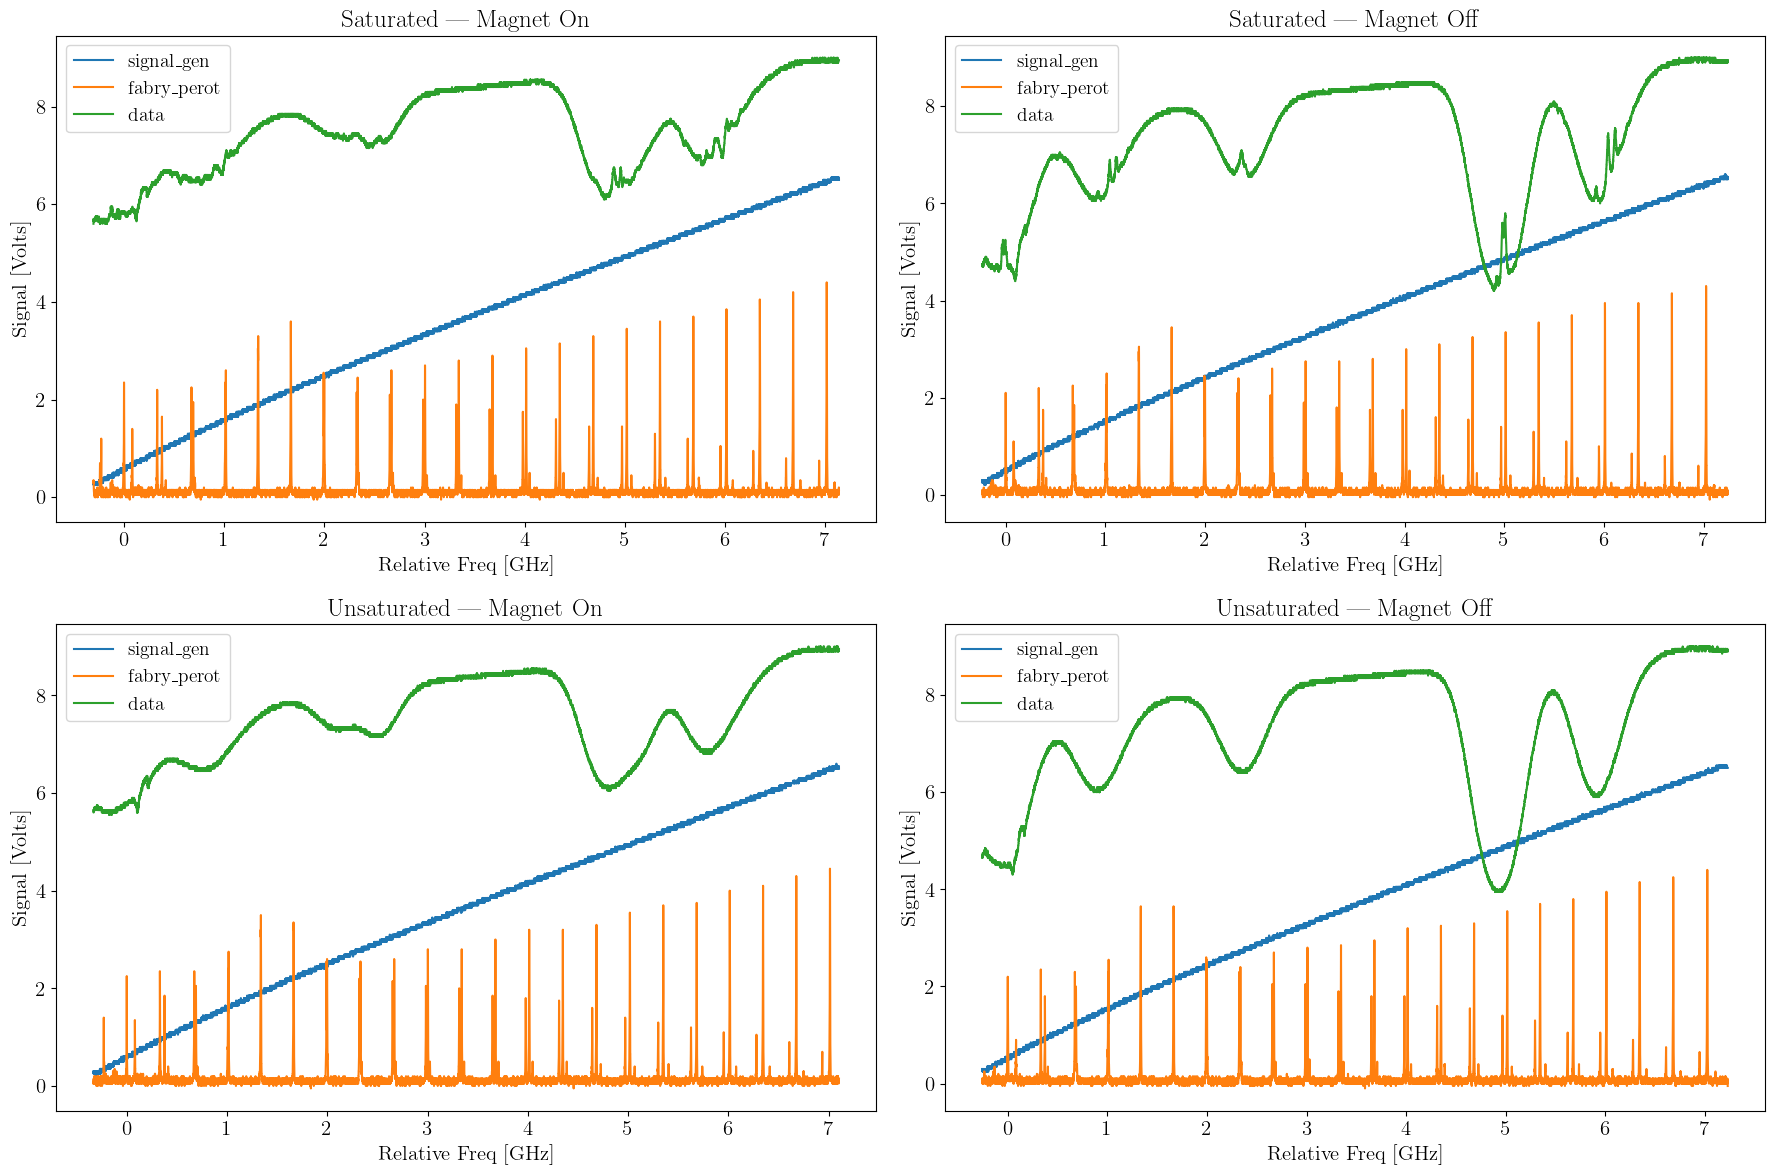

In [5]:
trim_start=3400
trim_stop=16770

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()  # easier indexing

subplot_idx = 0

for sat_type in data_dict.keys():
    for mag_stat in data_dict[sat_type].keys():
        ax = axes[subplot_idx]
        data_dfs = []
        df = data_dict[sat_type][mag_stat]["data"]
        for col in ["signal_gen", "fabry_perot", "data"]:
            ax.plot(df["freq"][trim_start:trim_stop], df[col][trim_start:trim_stop], label=col)

        ax.set_title(f"{sat_type.capitalize()} | {"Magnet On" if mag_stat=="magnet" else "Magnet Off"}")
        ax.set_xlabel("Relative Freq [GHz]")
        ax.set_ylabel("Signal [Volts]")
        ax.legend(fontsize=14)
        
        subplot_idx += 1

plt.tight_layout()
plt.savefig("DataSummary.png")
plt.show()

In [6]:
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes = axes.flatten()  # easier indexing

# subplot_idx = 0

# for sat_type in data_dict.keys():
#     for mag_stat in data_dict[sat_type].keys():
#         ax = axes[subplot_idx]
#         for dat_type in data_dict[sat_type][mag_stat].keys():
#             if dat_type=="fab_fit" or dat_type=="fab_cov" or dat_type=="fabry_perot":
#                 continue
#             df = data_dict[sat_type][mag_stat][dat_type]
#             # assuming columns are named 'time' and 'signal'
#             ax.plot(fabry_time_to_freq(np.asarray(df.iloc[:, 0]), *data_dict[sat_type][mag_stat]["fab_fit"]), df.iloc[:, 1], label=dat_type)
        
#         ax.set_title(f"{sat_type.capitalize()} | {"Magnet On" if mag_stat=="magnet" else "Magnet Off"}")
#         ax.set_xlabel("Relative Freq [GHz]")
#         ax.set_ylabel("Signal [Volts]")
#         ax.legend(fontsize=10)
        
#         subplot_idx += 1

# plt.tight_layout()
# plt.savefig("DataSummary.png")
# plt.show()

In [7]:
def absorption_model(x, a1, x1, b1, a2, x2, b2, a3, x3, b3, a4, x4, b4):
    return a1 * np.exp(-b1*(x-x1)**2) + a2 * np.exp(-b2*(x-x2)**2) + a3 * np.exp(-b3*(x-x3)**2) + a4 * np.exp(-b4*(x-x4)**2)

# fit this first to remove the curve in the data so that the multi-gaussian fit can be used
def laser_amp_curve_model(x, x0, a, b, c):
    return  a * (x-x0)**b  + c

def laser_amp_curve_model2(x, a, b, c, d):
    return  a * x**3 + b * x**2 + c * x + d

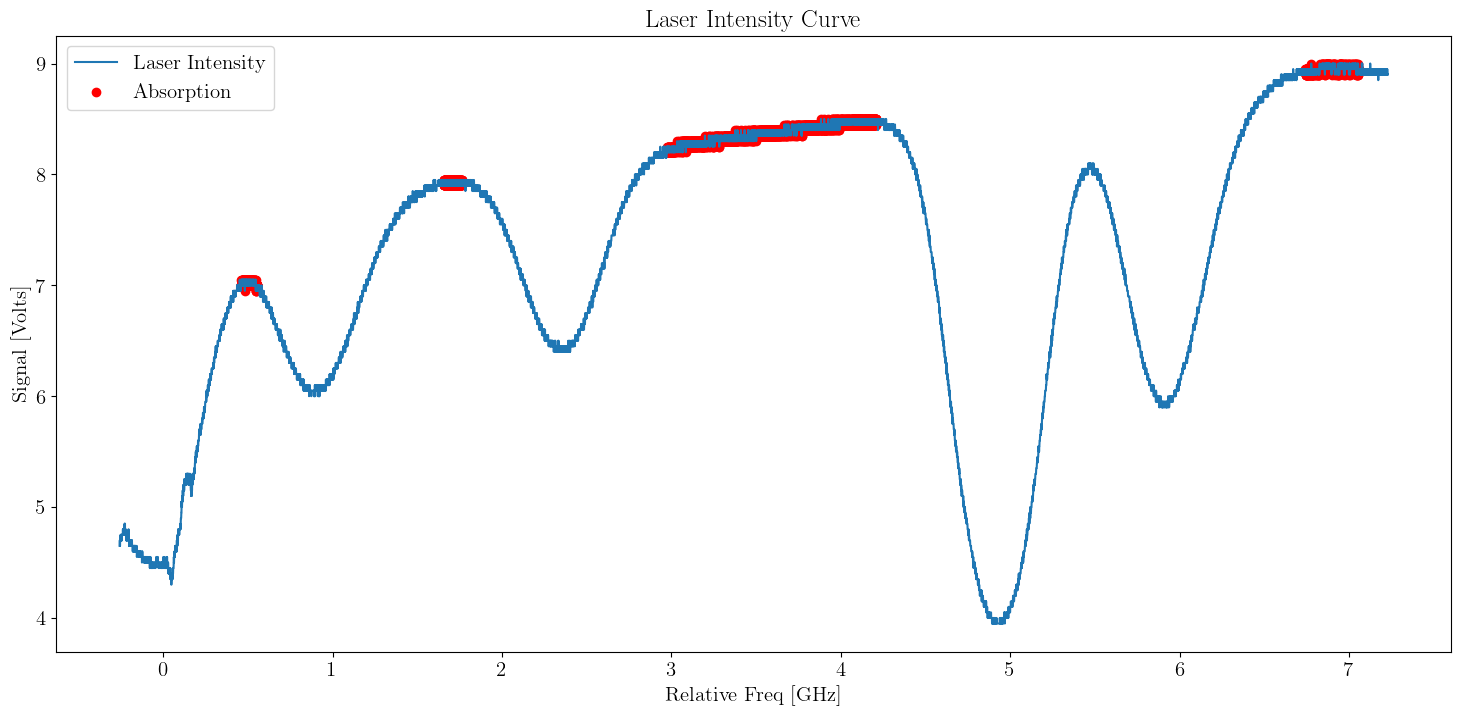

In [8]:
plt.figure(figsize=(18, 8))
# plt.scatter(data_dict["unsaturated"]["no_magnet"]["data"]["freq"][trim_start:trim_stop], data_dict["unsaturated"]["no_magnet"]["data"]["data"][trim_start:trim_stop], 
#                                s=.1, alpha=.2, c="purple", label="Data")

freqs = np.array(data_dict["unsaturated"]["no_magnet"]["data"]["freq"][trim_start:trim_stop])
signal = np.array(data_dict["unsaturated"]["no_magnet"]["data"]["data"][trim_start:trim_stop])

centers=[2750, 5800, 8500, 13000]
window_sizes=[1700, 3000, 3900, 3000]

xdata_chunks = []
ydata_chunks = []

centers2=[1750, 4100, 7400, 12850]
window_sizes2=[200, 200, 2100, 500]
for i in range (4):
    start=centers2[i] - int (window_sizes2[i]/2)
    stop=centers2[i] + int (window_sizes2[i]/2)

    xdata_chunks.append(freqs[start:stop])
    ydata_chunks.append(signal[start:stop])

power_curve_x = np.concat(xdata_chunks)
power_curve_y = np.concat(ydata_chunks)

plt.plot(freqs, signal)
plt.scatter(power_curve_x, power_curve_y, c="red")
plt.xlabel("Relative Freq [GHz]")
plt.ylabel("Signal [Volts]")
plt.title("Laser Intensity Curve")
plt.legend(["Laser Intensity", "Absorption"])

plt.show()

/tmp/ipykernel_9838/501905230.py:3: RuntimeWarning: invalid value encountered in power
  return  a * (x-x0)**b  + c


params: [0.40652098 1.22612551 0.36558902 6.50920397]


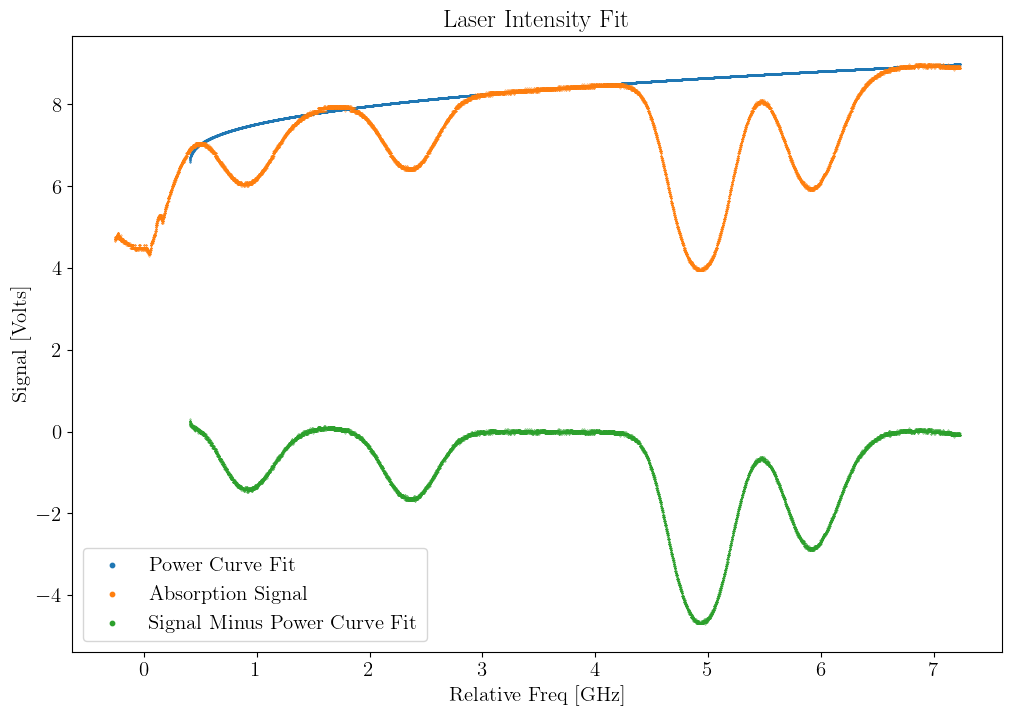

In [9]:
# fit this first to remove the curve in the data so that the multi-gaussian fit can be used
def laser_amp_curve_model(x, x0, a, b, c):
    return  a * (x-x0)**b  + c

def laser_amp_curve_model2(x, a, b, c, d):
    return  a * x**3 + b * x**2 + c * x + d

def linear(x, a, b):
    return a*x+b

def quad(x, a, b, c):
    return a * x **2 + b * x + c

def cubic(x, a, b, c, d):
    return a * x **3 + b * x **2 + c * x + d


# Optimize intensity curve
x0_guess=0
a_guess = 1.5
b_guess = .2
c_guess = 2
d_guess = 7

p0 = [x0_guess, a_guess, b_guess, c_guess]

las_int_popt, las_int_pcov = scipy.optimize.curve_fit(
    laser_amp_curve_model,
    power_curve_x,
    power_curve_y,
    p0=p0,
    maxfev=100000
)

print(f"params: {las_int_popt}")

power_curve_fit = laser_amp_curve_model(freqs, *las_int_popt)
plt.figure(figsize=(12,8))
plt.title("Laser Intensity Fit")
plt.xlabel("Relative Freq [GHz]")
plt.ylabel("Signal [Volts]")
plt.scatter(freqs, power_curve_fit,s=.1,label="Power Curve Fit")
plt.scatter(freqs, signal,s=.1,label="Absorption Signal")
plt.scatter(freqs, signal-power_curve_fit,s=.1,label="Signal Minus Power Curve Fit")
plt.legend(markerscale=10)
# plt.savefig()
plt.show()


p0: [-2, 1, 0.7, -2, 2.0, 0.7, -4, 5, 0.7, -3, 6, 0.7]


/tmp/ipykernel_9838/3051079793.py:2: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1*(x-x1)**2) + a2 * np.exp(-b2*(x-x2)**2) + a3 * np.exp(-b3*(x-x3)**2) + a4 * np.exp(-b4*(x-x4)**2)


[ 1399.68231118     1.66880935     2.5837699  -1399.34313311
     1.66888657     2.57677514    -4.84618031     4.9276803
     8.41114816    -2.88792477     5.92453551     9.69660717]


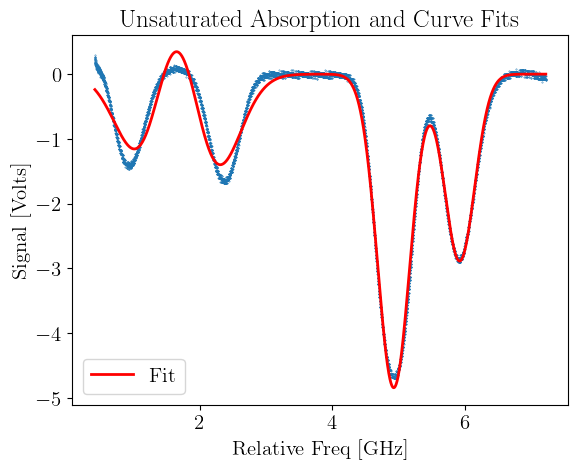

In [13]:
fits = []

# transform data by subtracting the power curve fit


def trim_leading_nans(x, y):
    first_valid = np.argmax(~np.isnan(y))
    return x[first_valid:], y[first_valid:]

xdata, ydata = trim_leading_nans(freqs, signal-power_curve_fit)

#  model: a * np.exp(-b * (x - x0)**2) + c * x + d
a1_guess = -2
x1_guess = 1
b1_guess = .7

a2_guess = -2
x2_guess = 2.
b2_guess = .7

a3_guess = -4
x3_guess = 5
b3_guess = .7

a4_guess = -3
x4_guess = 6
b4_guess = .7

p0 = [a1_guess, x1_guess, b1_guess, a2_guess, x2_guess, b2_guess, a3_guess, x3_guess, b3_guess, a4_guess, x4_guess, b4_guess]
print(f"p0: {p0}")
# optional bounds
# bounds = (
#     [xdata.min(), -np.inf, 0, -np.inf, -np.inf],   # lower
#     [xdata.max(), 0,      np.inf, np.inf,  np.inf] # upper
# )

popt, pcov = scipy.optimize.curve_fit(
    absorption_model,
    xdata,
    ydata,
    p0=p0,
    #bounds=bounds,
    maxfev=20000
)

print(popt)
fits.append((popt, pcov))

# # fitted parameters
# x0_fit, a_fit, b_fit, c_fit, d_fit = popt

# # uncertainties (standard deviation of parameters)
# perr = np.sqrt(np.diag(pcov))

# # helper for 4 significant figures
# def fmt(x):
#     return f"{x:.4g}"

# # formatted model string
# model_str = (
#     f"T(x) = ({a_fit} ± {perr[1]}) * exp[-({b_fit} ± {perr[2]}) (x - ({x0_fit} ± {perr[0]}))^2] "
#     f"+ ({c_fit} ± {perr[3]}) x + ({d_fit} ± {perr[4]})"
# )

# print(f"Peak {i+1} fit:")
# print(model_str)

# fitted curve
xfit = np.linspace(xdata.min(), xdata.max(), 2000)
yfit = absorption_model(xfit, *popt)
plt.plot(xfit, yfit, linewidth=2, label=f"Fit",color="Red")
plt.scatter(xdata, ydata,s=.1)

plt.xlabel("Relative Freq [GHz]")
plt.ylabel("Signal [Volts]")
plt.title("Unsaturated Absorption and Curve Fits")
plt.legend()
# plt.savefig("DopplerFits.png")
plt.show()

The four peaks are centered at $\omega_1=.9095, \omega_2=2.3596, \omega_3=4.9291, \omega_4=5.9104$ Ghz

Let's make a guess as to what the theoretical model should predict - for a peak centered at $\omega_1=.9095$, which could either be Rubidium-85 or Rubidium-87, we would like to predict the approximate width of the peak (in GHz)


Expect absorption to be $$g(\omega)=\frac{c}{u \omega_0 \sqrt{\pi}}\text{exp}\left(-\frac{c^2}{u^2}\left(\frac{\omega - \omega_0}{\omega_0}\right)^2\right)$$

Which means that the Transmittance would be the inverse:

$$T(\omega)=V_{0}-A\frac{c}{u \omega_0 \sqrt{\pi}}\text{exp}\left(-\frac{c^2}{u^2}\left(\frac{\omega - \omega_0}{\omega_0}\right)^2\right)$$

Model is of the form: $A e^{-B(\omega-\omega_0)^2}+Cx+D$
calculate $B$ as $-\frac{c^2}{u^2\omega_0^2}$, which for $^{85}$ Rb, 
$-\frac{c^2}{u^2\omega_0^2}=-\frac{299792458^2}{249^2 * \omega_0^2}=-9.05$

But -9.05 is in units of gigahertz, so this should be expected to 

$$\omega_0^2 = \frac{299792458^2}{249^2*9.05} \approx 1.60174778635\times10^{11} GHz$$, or $$1.60174778635\times10^{20} Hz$$

In [ ]:

# Chamber temp
chamber_temp = 45.2
v_laser = 5
# scan freq
c=299792458
k_b=1.38065e-23
T=273.15 + chamber_temp
N_a = 6.022e23
m85_amu = 84.91
m87_amu = 86.91
m85_kg = m85_amu / (N_a*1000)
m87_kg = m87_amu / (N_a*1000)

u85 = np.sqrt(2*k_b*T / m85_kg)
u87 = np.sqrt(2*k_b*T / m87_kg)
omega_0=c/750e-9
print(f"m85_kg: {m85_kg}\nu85: {u85}\nc: {c} m/s\n")
print(f"m87_kg: {m87_kg}\nu87: {u87}\nc: {c} m/s\n")

# The width of the doppler broadened distribution is somewhere in the range of several hundred megahertz. For a resonant frequency of c/750e-9, we expect to see the absorption spectrum from c/750e-9+-560MHz (FWHM)
# This translates to frequencies of between 3.997 227 173 33e14 to 3.997 238 373 33e14 Hz. 

# freq_vals = np.linspace(c/(c/750e-9-560e6), c/(c/750e-9+560e6), 1000)

m85_kg: 1.4099966788442375e-25
u85: 249.68944193979328
c: 299792458 m/s

m87_kg: 1.4432082364662901e-25
u87: 246.7997549674793
c: 299792458 m/s



In [ ]:
# Implement  in SI units
def g_d(omega, c, u, omega_0):
    scale = (c / (u * omega_0 * np.sqrt(np.pi)))
    print(scale)
    exp_scale = -c**2/(u**2)
    #print(f"Exp scale: {exp_scale}")
    exp_val = ((omega-omega_0)/omega_0)**2
    #print(f"Exp val: {exp_val}")
    exp = np.exp(- (c**2 / u**2) * ((omega - omega_0) / omega_0)**2)
    #print(f"Exp: {exp}")
    return scale*exp
print(f"Frequency of light with wavelength 750nm: {c/750e-9:.4g} Hz")
print(g_d(c/750e-9, c, u85, omega_0))


Frequency of light with wavelength 750nm: 3.997e+14 Hz
1.6946739292358545e-09
1.694612770222251e-09


In [ ]:
# pred_abs = np.zeros_like(freq_vals)
# for i in range(len(pred_abs)):
#     pred_abs[i]=g_d(c/freq_vals[i], c, u85, omega_0)

# print(freq_vals)
# print(pred_abs)
# plt.scatter(freq_vals, pred_abs)

In [ ]:
dp_broadened = pd.read_csv("TEK00074.CSV", skiprows=15)
dp_broadened.head(20)

In [ ]:
plt.figure(figsize=(18, 6))
plt.ylabel("Volts")
plt.xlabel("Time")
plt.plot(dp_broadened["TIME"], dp_broadened["CH4"]/100)


In [ ]:
sat_abs = pd.read_csv("TEK00071.CSV", skiprows=15)
plt.figure(figsize=(18,6))
plt.xlabel("Time"); plt.ylabel("Volts")
plt.plot(sat_abs["TIME"], sat_abs["CH4"]/100)

In [ ]:
# div=.01
# satmag = readrbdata.load(sat=True, mag=True)
# unsatmag = readrbdata.load(sat=False, mag=True)

# uns_interp = np.interp(satmag.time, unsatmag.time, unsatmag.signal)
# fig, ax = plt.subplots(figsize=(16,8))
# ax.scatter(satmag.time, satmag.signal, label="Saturated Magnet Signal", s=.01)
# ax.scatter(satmag.time, uns_interp, label="Unsaturated Signal (interpolated)", s=.01)
# ax.plot(satmag.time, satmag.signal - uns_interp, label="Signal Difference (sat-unsat)")
# ax.set_title("Saturated Signal and (saturated-unsaturated)")
# ax.legend()
# ax.set_ylabel("Voltage")
# ax.set_xlabel("Time")

# # plt.figure(figsize=(16,8))
# # plt.scatter(satmag.time, np.asarray(satmag.signal)*div, s=.1)
# # plt.scatter(unsatmag.time, np.asarray(unsatmag.signal)*div, s=.1)
# # plt.legend(["Saturated Magnet", "Unsaturated Magnet"], markerscale=15)
